In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from prophet import Prophet

warnings.filterwarnings("ignore")

In [4]:
df = pd.read_csv("TS 1.csv")

df["Time"] = pd.to_datetime(df["Time"])
df = df.set_index("Time").sort_index()

df.head()

print("Размер:", df.shape)
print("Начало:", df.index.min())
print("Конец:", df.index.max())
print("Пропуски:", df.isna().sum())

Размер: (2625, 1)
Начало: 2017-01-01 00:00:00
Конец: 2017-04-20 09:00:00
Пропуски: Users    0
dtype: int64


In [5]:
full_index = pd.date_range(
    start=df.index.min(),
    end=df.index.max(),
    freq="h"
)

df = df.reindex(full_index)

# Заполняем пропуск
df["Users"] = df["Users"].interpolate(method="time")

print(df.isna().sum())

Users    0
dtype: int64


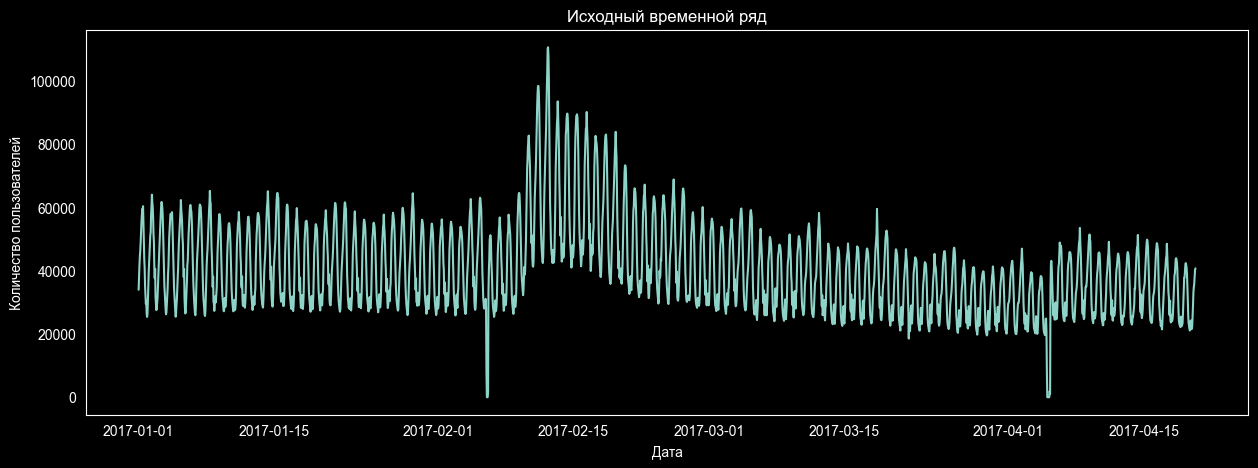

In [6]:
plt.figure(figsize=(15, 5))

plt.plot(df.index, df["Users"])

plt.title("Исходный временной ряд")
plt.xlabel("Дата")
plt.ylabel("Количество пользователей")
plt.grid()

plt.show()

In [7]:
train = df.loc[df.index < "2017-04-01", "Users"]
test = df.loc[df.index >= "2017-04-01", "Users"]

print("Train:", train.index.min(), "-", train.index.max())
print("Test:", test.index.min(), "-", test.index.max())

print("Train:", len(train))
print("Test:", len(test))

Train: 2017-01-01 00:00:00 - 2017-03-31 23:00:00
Test: 2017-04-01 00:00:00 - 2017-04-20 09:00:00
Train: 2160
Test: 466


ARIMA

In [8]:
result = adfuller(train)

print("ADF:", result[0])
print("p-value:", result[1])

ADF: -1.8732426566612876
p-value: 0.3447513838620019


In [9]:
train_diff = train.diff().dropna()

result = adfuller(train_diff)

print("ADF:", result[0])
print("p-value:", result[1])

ADF: -11.826080486286275
p-value: 8.197372296513735e-22


In [10]:
best_aic = np.inf
best_order = None
results = []

for p in range(6):
    for q in range(6):

        if p == 0 and q == 0:
            continue

        try:
            model = ARIMA(
                train,
                order=(p, 1, q),
                enforce_stationarity=False,
                enforce_invertibility=False
            )

            model_fit = model.fit()

            results.append([p, 1, q, model_fit.aic])

            if model_fit.aic < best_aic:
                best_aic = model_fit.aic
                best_order = (p, 1, q)

        except:
            pass

In [11]:
results_df = pd.DataFrame(
    results,
    columns=["p", "d", "q", "AIC"]
)

results_df = results_df.sort_values("AIC")

results_df.head(10)

,p,d,q,AIC
28,4,1,5,39576.530553
34,5,1,5,39576.754692
33,5,1,4,39624.362166
27,4,1,4,39637.911013
16,2,1,5,39666.833255
21,3,1,4,39687.742225
26,4,1,3,39697.807027
15,2,1,4,39700.309832
20,3,1,3,39745.157326
25,4,1,2,39754.803379


In [12]:
print("Лучший порядок:", best_order)
print("AIC:", best_aic)

Лучший порядок: (4, 1, 5)
AIC: 39576.53055341373


In [13]:
model = ARIMA(
    train,
    order=best_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  Users   No. Observations:                 2160
Model:                 ARIMA(4, 1, 5)   Log Likelihood              -19778.265
Date:                Mon, 05 Oct 2026   AIC                          39576.531
Time:                        15:01:07   BIC                          39633.277
Sample:                    01-01-2017   HQIC                         39597.289
                         - 03-31-2017                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6057      0.043     14.045      0.000       0.521       0.690
ar.L2          0.6509      0.058     11.161      0.000       0.537       0.765
ar.L3          0.3919      0.052      7.556      0.0

In [14]:
forecast = model_fit.forecast(steps=len(test))

forecast.index = test.index

forecast.head()

2017-04-01 00:00:00    30594.622685
2017-04-01 01:00:00    32876.527154
2017-04-01 02:00:00    35128.200697
2017-04-01 03:00:00    37010.224434
2017-04-01 04:00:00    38549.320210
Freq: h, Name: predicted_mean, dtype: float64

In [15]:
mae = mean_absolute_error(test, forecast)
mse = mean_squared_error(test, forecast)
rmse = np.sqrt(mse)
r2 = r2_score(test, forecast)

mask = test != 0

mape = np.mean(
    np.abs((test[mask] - forecast[mask]) / test[mask])
) * 100

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.4f}")
print(f"MAPE: {mape:.2f}%")

MAE: 6930.07
MSE: 79285563.21
RMSE: 8904.24
R²: 0.1288
MAPE: 30.24%


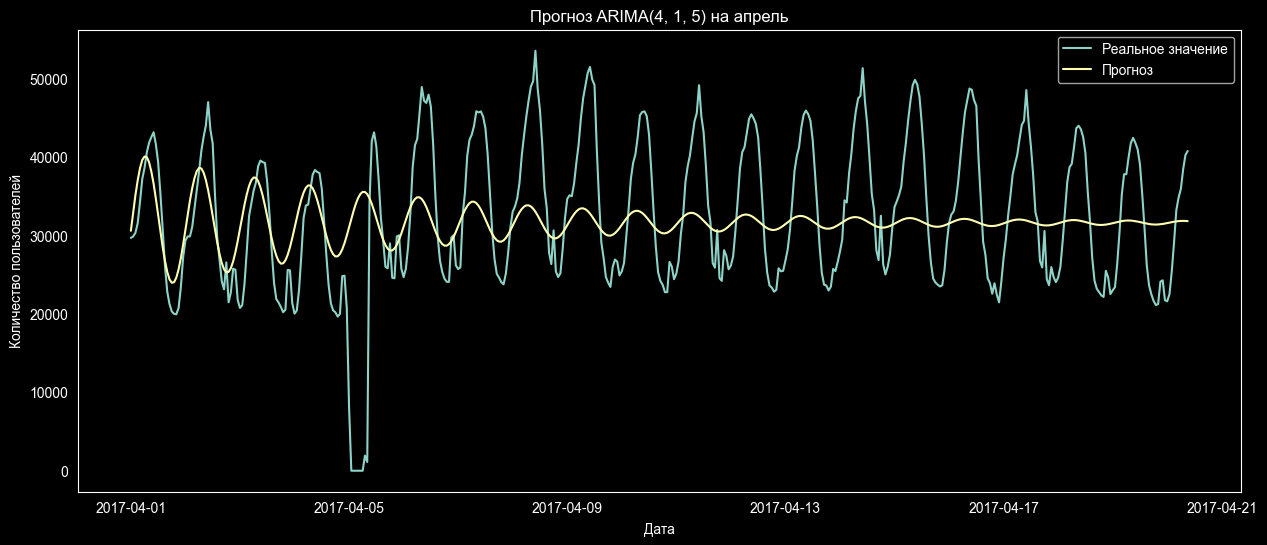

In [16]:
plt.figure(figsize=(15, 6))

plt.plot(test.index, test, label="Реальное значение")
plt.plot(forecast.index, forecast, label="Прогноз")

plt.title(f"Прогноз ARIMA{best_order} на апрель")
plt.xlabel("Дата")
plt.ylabel("Количество пользователей")

plt.legend()
plt.grid()

plt.show()

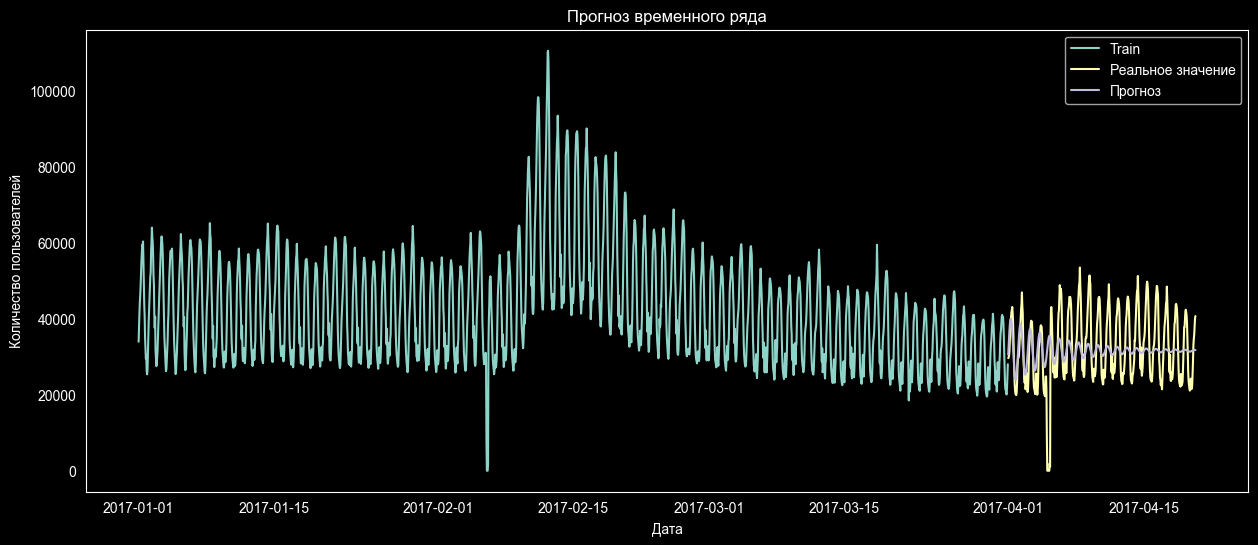

In [17]:
plt.figure(figsize=(15, 6))

plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Реальное значение")
plt.plot(forecast.index, forecast, label="Прогноз")

plt.title("Прогноз временного ряда")
plt.xlabel("Дата")
plt.ylabel("Количество пользователей")

plt.legend()
plt.grid()

plt.show()

SARIMA

In [19]:
model_sarima = SARIMAX(
    train,
    order=(4, 1, 5),
    seasonal_order=(1, 0, 1, 24),
    enforce_stationarity=False,
    enforce_invertibility=False
)

model_sarima_fit = model_sarima.fit(disp=False)

In [20]:
forecast_sarima = model_sarima_fit.forecast(steps=len(test))
forecast_sarima.index = test.index

In [21]:
mae = mean_absolute_error(test, forecast_sarima)
mse = mean_squared_error(test, forecast_sarima)
rmse = np.sqrt(mse)
r2 = r2_score(test, forecast_sarima)

mask = test != 0
mape = np.mean(
    np.abs((test[mask] - forecast_sarima[mask]) / test[mask])
) * 100

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.4f}")
print(f"MAPE: {mape:.2f}%")

MAE: 3786.90
MSE: 36398623.27
RMSE: 6033.13
R²: 0.6000
MAPE: 21.72%


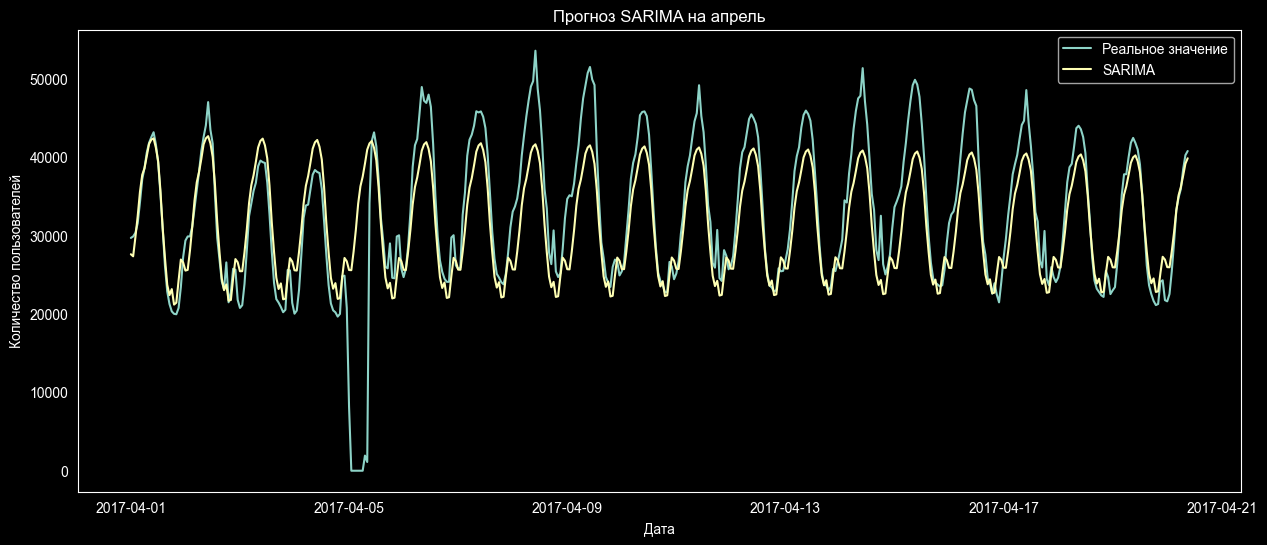

In [22]:
plt.figure(figsize=(15, 6))

plt.plot(test.index, test, label="Реальное значение")
plt.plot(forecast_sarima.index, forecast_sarima, label="SARIMA")

plt.title("Прогноз SARIMA на апрель")
plt.xlabel("Дата")
plt.ylabel("Количество пользователей")

plt.legend()
plt.grid()
plt.show()

Holt-Winters

In [26]:
model_hw = ExponentialSmoothing(
    train,
    trend="add",
    seasonal="add",
    seasonal_periods=24
)

model_hw_fit = model_hw.fit()

In [27]:
forecast_hw = model_hw_fit.forecast(len(test))
forecast_hw.index = test.index

In [28]:
mae_hw = mean_absolute_error(test, forecast_hw)
mse_hw = mean_squared_error(test, forecast_hw)
rmse_hw = np.sqrt(mse_hw)
r2_hw = r2_score(test, forecast_hw)

mask = test != 0

mape_hw = np.mean(
    np.abs((test[mask] - forecast_hw[mask]) / test[mask])
) * 100

print(f"MAE: {mae_hw:.2f}")
print(f"MSE: {mse_hw:.2f}")
print(f"RMSE: {rmse_hw:.2f}")
print(f"R²: {r2_hw:.4f}")
print(f"MAPE: {mape_hw:.2f}%")

MAE: 5741.13
MSE: 64411433.73
RMSE: 8025.67
R²: 0.2922
MAPE: 31.91%


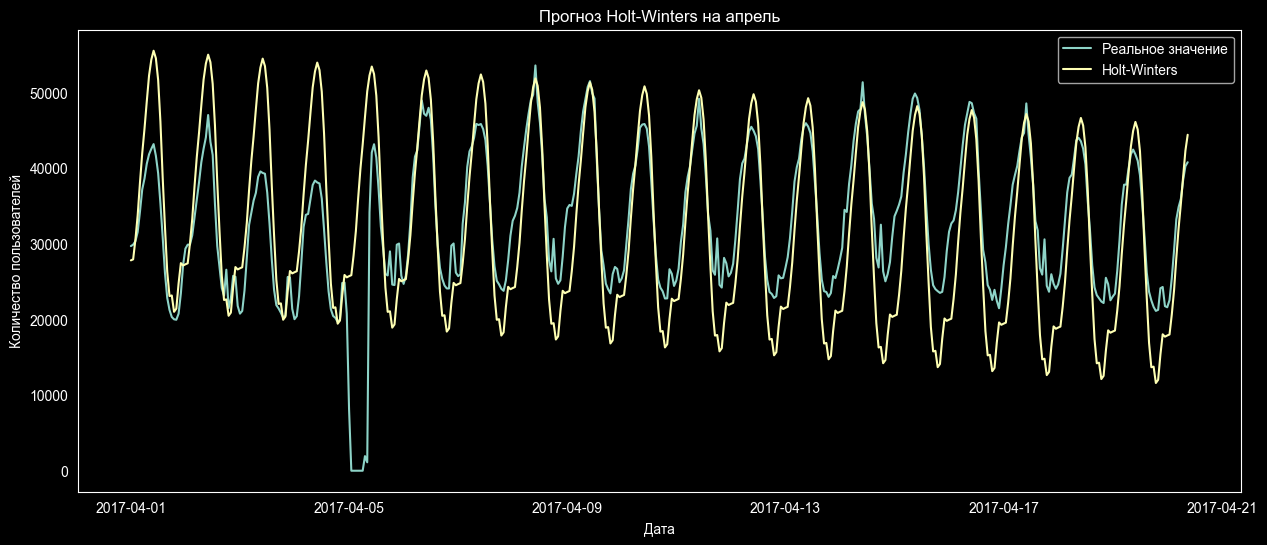

In [29]:
plt.figure(figsize=(15, 6))

plt.plot(test.index, test, label="Реальное значение")
plt.plot(forecast_hw.index, forecast_hw, label="Holt-Winters")

plt.title("Прогноз Holt-Winters на апрель")
plt.xlabel("Дата")
plt.ylabel("Количество пользователей")

plt.legend()
plt.grid()

plt.show()

Prophet

In [33]:
train_prophet = train.reset_index()
train_prophet.columns = ["ds", "y"]

test_prophet = test.reset_index()
test_prophet.columns = ["ds", "y"]

train_prophet.head()

,ds,y
0,2017-01-01 00:00:00,34002.0
1,2017-01-01 01:00:00,37947.0
2,2017-01-01 02:00:00,41517.0
3,2017-01-01 03:00:00,44476.0
4,2017-01-01 04:00:00,46234.0


In [34]:
model_prophet = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=False
)

model_prophet.fit(train_prophet)

15:26:25 - cmdstanpy - INFO - Chain [1] start processing
15:26:25 - cmdstanpy - INFO - Chain [1] done processing


In [35]:
future = pd.DataFrame({
    "ds": test.index
})

forecast_prophet_full = model_prophet.predict(future)

forecast_prophet = forecast_prophet_full["yhat"]
forecast_prophet.index = test.index

forecast_prophet.head()

2017-04-01 00:00:00    23843.937207
2017-04-01 01:00:00    25245.211539
2017-04-01 02:00:00    28309.310440
2017-04-01 03:00:00    33016.763114
2017-04-01 04:00:00    38275.265424
Freq: h, Name: yhat, dtype: float64

In [36]:
mae_prophet = mean_absolute_error(test, forecast_prophet)
mse_prophet = mean_squared_error(test, forecast_prophet)
rmse_prophet = np.sqrt(mse_prophet)
r2_prophet = r2_score(test, forecast_prophet)

mask = test != 0

mape_prophet = np.mean(
    np.abs((test[mask] - forecast_prophet[mask]) / test[mask])
) * 100

print(f"MAE: {mae_prophet:.2f}")
print(f"MSE: {mse_prophet:.2f}")
print(f"RMSE: {rmse_prophet:.2f}")
print(f"R²: {r2_prophet:.4f}")
print(f"MAPE: {mape_prophet:.2f}%")

MAE: 7728.40
MSE: 85331821.98
RMSE: 9237.52
R²: 0.0623
MAPE: 37.10%


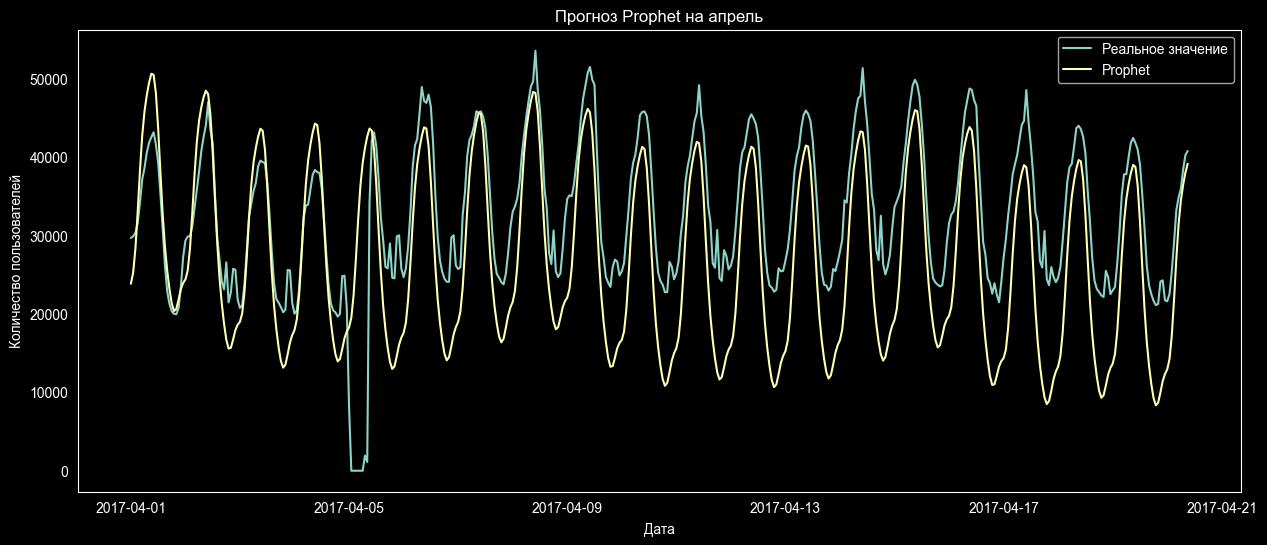

In [37]:
plt.figure(figsize=(15, 6))

plt.plot(test.index, test, label="Реальное значение")
plt.plot(forecast_prophet.index, forecast_prophet, label="Prophet")

plt.title("Прогноз Prophet на апрель")
plt.xlabel("Дата")
plt.ylabel("Количество пользователей")

plt.legend()
plt.grid()

plt.show()

In [38]:
comparison = pd.DataFrame({
    "Модель": [
        "ARIMA",
        "SARIMA",
        "Holt-Winters",
        "Prophet"
    ],
    "MAE": [
        6930.07,
        3786.90,
        5741.13,
        mae_prophet
    ],
    "RMSE": [
        8904.24,
        6033.13,
        8025.67,
        rmse_prophet
    ],
    "R²": [
        0.1288,
        0.6000,
        0.2922,
        r2_prophet
    ],
    "MAPE": [
        30.24,
        21.72,
        31.91,
        mape_prophet
    ]
})

comparison

,Модель,MAE,RMSE,R²,MAPE
0,ARIMA,6930.070000,8904.240000,0.128800,30.240000
1,SARIMA,3786.900000,6033.130000,0.600000,21.720000
2,Holt-Winters,5741.130000,8025.670000,0.292200,31.910000
3,Prophet,7728.402479,9237.522502,0.062329,37.104728
